<a href="https://colab.research.google.com/github/AvisarBhandari/Ml/blob/main/02_pytorch_classification_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import torch
import torch

# Setup device agnostic code
device="cuda" if torch.cuda.is_available() else  "cpu"
# Setup random seed
RANDOM_SEED = 42
device

'cuda'

In [3]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
n_sample=1000
X_moons,Y_moons = make_moons(n_samples=n_sample,
                             noise=0.3,
                             random_state=RANDOM_SEED)
X_moons = torch.from_numpy(X_moons).to(dtype=torch.float)
Y_moons = torch.from_numpy(Y_moons).to(dtype=torch.float)

X_train,X_test,Y_train,Y_test = train_test_split(X_moons,
                                                 Y_moons,
                                                 test_size=0.2,
                                                 random_state=RANDOM_SEED)
len(X_train),len(X_test),len(Y_train),len(Y_test),X_train.type(),torch.unique(Y_moons)

(800, 200, 800, 200, 'torch.FloatTensor', tensor([0., 1.]))

In [4]:
# Turn data into a DataFrame
import pandas as pd
moons= pd.DataFrame({"X1":X_moons[:,0],
                    "X2":X_moons[:,1],
                    "Label":Y_moons})
moons.head(5)

,X1,X2,Label
0,-0.171863,0.596249,1.0
1,1.253283,-0.265414,1.0
2,0.723224,0.231943,1.0
3,-0.065198,-0.655194,1.0
4,-0.799493,0.552935,0.0


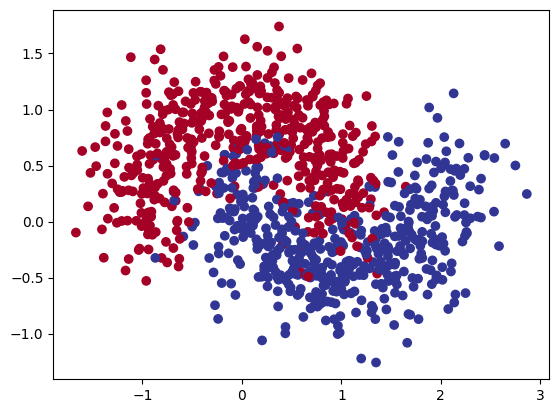

In [5]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.figure
plt.scatter(x=X_moons[:,0],
            y=X_moons[:,1],
            c=Y_moons,cmap=plt.cm.RdYlBu)

In [6]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
  ## Your code here ##
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2 , out_features=10)
    self.layer_2 = nn.Linear(in_features=10 , out_features=10)
    self.layer_3 = nn.Linear(in_features=10 , out_features=1)
    self.relu= nn.ReLU();

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

# Instantiate the model
model_0 = MoonModelV0().to(device)
model_0


MoonModelV0(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [7]:
# Setup loss function
loss_fn = torch.nn.BCEWithLogitsLoss()
# Setup optimizer to optimize model's parameters
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.1)

In [8]:
# What's coming out of our model?
model_0.eval()
with torch.inference_mode():
  logits= model_0(X_test.to(device))
# logits (raw outputs of model)
print("Logits:", logits[:10])

pred_porbs = torch.sigmoid(logits)
# Prediction probabilities
print("Pred probs:",pred_porbs[:10])

pred_label = torch.argmax(pred_porbs,dim=1)
# Prediction labels
print("Pred labels:",pred_label[:10])
## Your code here ##

Logits: tensor([[0.3012],
        [0.2394],
        [0.2756],
        [0.2105],
        [0.3032],
        [0.2960],
        [0.2536],
        [0.2538],
        [0.3024],
        [0.2335]], device='cuda:0')
Pred probs: tensor([[0.5747],
        [0.5596],
        [0.5685],
        [0.5524],
        [0.5752],
        [0.5735],
        [0.5631],
        [0.5631],
        [0.5750],
        [0.5581]], device='cuda:0')
Pred labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], device='cuda:0')


In [9]:
# Let's calculuate the accuracy using accuracy from TorchMetrics
!pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

acc_fn = Accuracy(task="binary").to(device)
acc_fn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.4 MB/s eta 0:00:00


BinaryAccuracy()

In [10]:
Y_train = Y_train.unsqueeze(1)
Y_test = Y_test.unsqueeze(1)
Y_train.shape

torch.Size([800, 1])

In [11]:
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
# Setup epochs
epochs = 1000

# Send data to the device
X_test , Y_test = X_test.to(device),Y_test.to(device)
X_train, Y_train = X_train.to(device), Y_train.to(device)

# Loop through the data
for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass (logits output)
  logits = model_0(X_train)

  # Turn logits into prediction probabilities
  pred_porbs = torch.sigmoid(logits)

  # Turn prediction probabilities into prediction labels
  pred_label = torch.round(pred_porbs)

  # print(logits.shape, Y_train.shape)
  # 2. Calculaute the loss
  loss = loss_fn(logits, Y_train) # loss = compare model raw outputs to desired model outputs

  # Calculate the accuracy
  acc = acc_fn(pred_label, Y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  model_0.zero_grad()

  # 4. Loss backward (perform backpropagation)
  loss.backward()
  # 5. Step the optimizer (gradient descent)
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass (to get the logits)
    test_logits = model_0(X_test)


    # Turn the test logits into prediction labels
    test_label = torch.sigmoid(test_logits)

    test_pred = torch.round(test_label)
    # 2. Caculate the test loss/acc
    test_loss = loss_fn(test_pred, Y_test)
    test_acc = acc_fn(test_pred, Y_test.int())


  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch:{epoch} | train Loss:{loss} | train Acc:{acc} | test Loss {test_loss} | test acc:{test_acc}")


Epoch:0 | train Loss:0.6933130025863647 | train Acc:0.5 | test Loss 0.6019746661186218 | test acc:0.7400000095367432
Epoch:100 | train Loss:0.195301353931427 | train Acc:0.9200000166893005 | test Loss 0.545802116394043 | test acc:0.9100000262260437
Epoch:200 | train Loss:0.18423743546009064 | train Acc:0.9225000143051147 | test Loss 0.5401039123535156 | test acc:0.925000011920929
Epoch:300 | train Loss:0.17852962017059326 | train Acc:0.9212499856948853 | test Loss 0.5401039123535156 | test acc:0.925000011920929
Epoch:400 | train Loss:0.17194952070713043 | train Acc:0.925000011920929 | test Loss 0.5432044267654419 | test acc:0.9200000166893005
Epoch:500 | train Loss:0.18903867900371552 | train Acc:0.9125000238418579 | test Loss 0.5444055795669556 | test acc:0.9200000166893005
Epoch:600 | train Loss:0.16890689730644226 | train Acc:0.9237499833106995 | test Loss 0.5432044267654419 | test acc:0.9200000166893005
Epoch:700 | train Loss:0.16744694113731384 | train Acc:0.925000011920929 | test

In [12]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):

    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

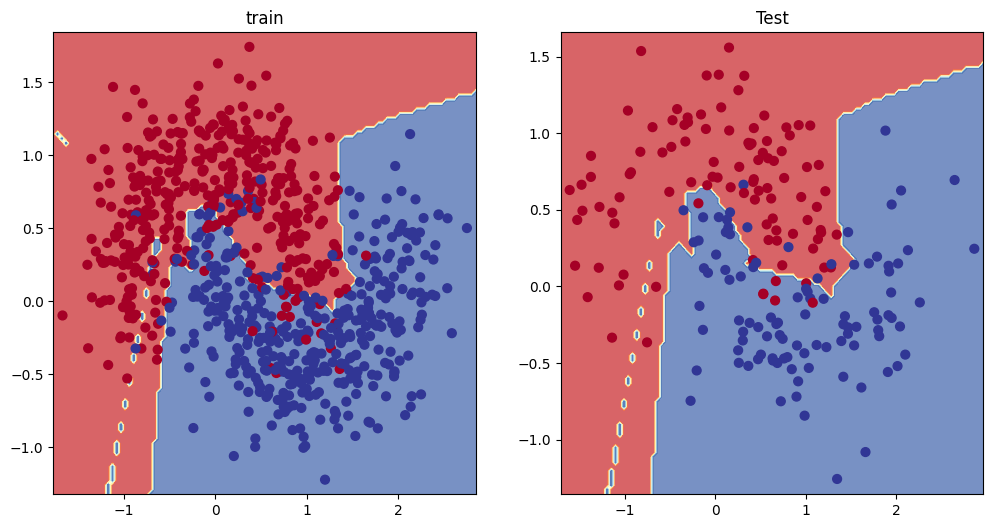

In [13]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_0,X_train,Y_train)

plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,Y_test)

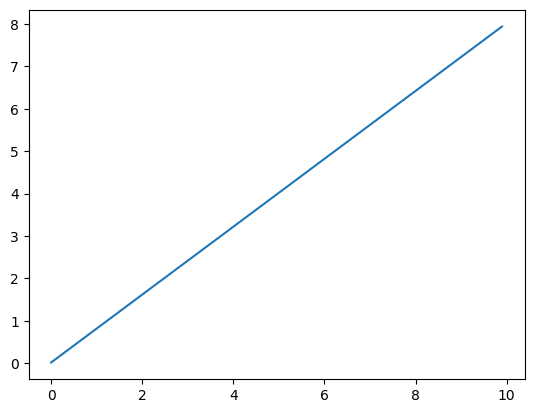

In [14]:
# Create a straight line tensor
start = 0
end = 10
step = 0.10
wight=0.8
bias=.02
x = torch.arange(start, end, step)
y= wight*x+bias
plt.plot(x,y)

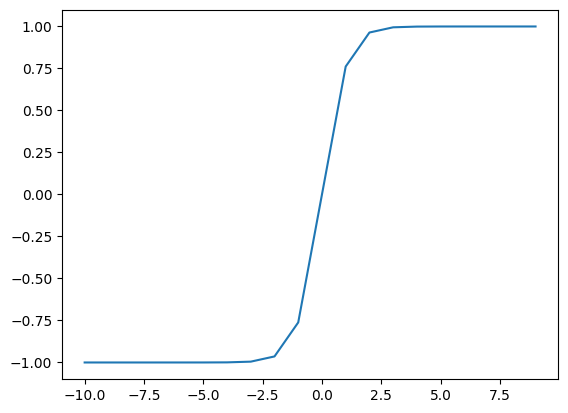

In [15]:
# Test torch.tanh() on the tensor and plot it
import numpy as np
x= torch.arange(-10,10)
y= torch.tanh(x)
plt.plot(x,y)

/tmp/ipykernel_2505/3531978002.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y= (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))


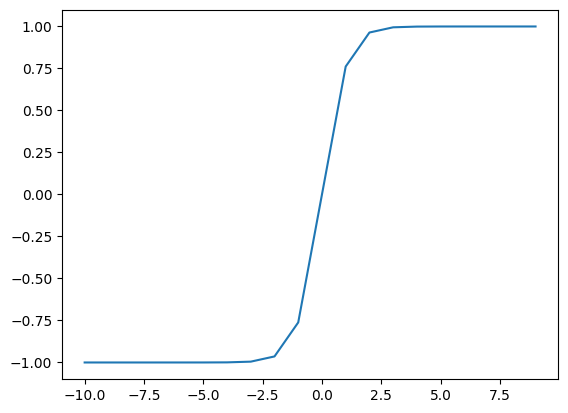

In [16]:
# Replicate torch.tanh() and plot it
import numpy as np
x= torch.arange(-10,10)
y= (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
plt.plot(x,y)


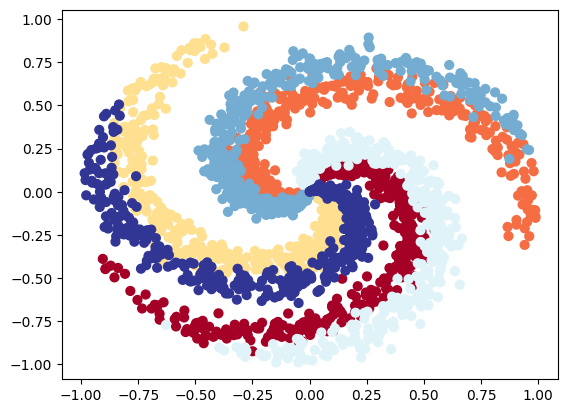

In [38]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 400 # number of points per class
D = 2 # dimensionality
K = 6 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [39]:
# Turn data into tensors
import torch
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,
                                                 y,
                                                 random_state=42,
                                                 test_size=0.2)

In [40]:
len(x_train),len(x_test), y_train.shape

(1920, 480, torch.Size([1920]))

In [41]:
# Let's calculuate the accuracy for when we fit our model
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=6).to(device)
acc_fn


MulticlassAccuracy()

In [45]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class Spriral_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_stacks = nn.Sequential(nn.Linear(2,80),
                                      nn.ReLU(),
                                      nn.Linear(80,80),
                                      nn.ReLU(),
                                       nn.Linear(80,80),
                                      nn.ReLU(),
                                       nn.Linear(80,80),
                                      nn.ReLU(),
                                      nn.Linear(80,80),
                                      nn.ReLU(),
                                      nn.Linear(80,6))
  def forward(self,x):
    return self.layer_stacks(x)

# Instantiate model and send it to device
model_1 = Spriral_model()
model_1.to(device)

Spriral_model(
  (layer_stacks): Sequential(
    (0): Linear(in_features=2, out_features=80, bias=True)
    (1): ReLU()
    (2): Linear(in_features=80, out_features=80, bias=True)
    (3): ReLU()
    (4): Linear(in_features=80, out_features=80, bias=True)
    (5): ReLU()
    (6): Linear(in_features=80, out_features=80, bias=True)
    (7): ReLU()
    (8): Linear(in_features=80, out_features=80, bias=True)
    (9): ReLU()
    (10): Linear(in_features=80, out_features=6, bias=True)
  )
)

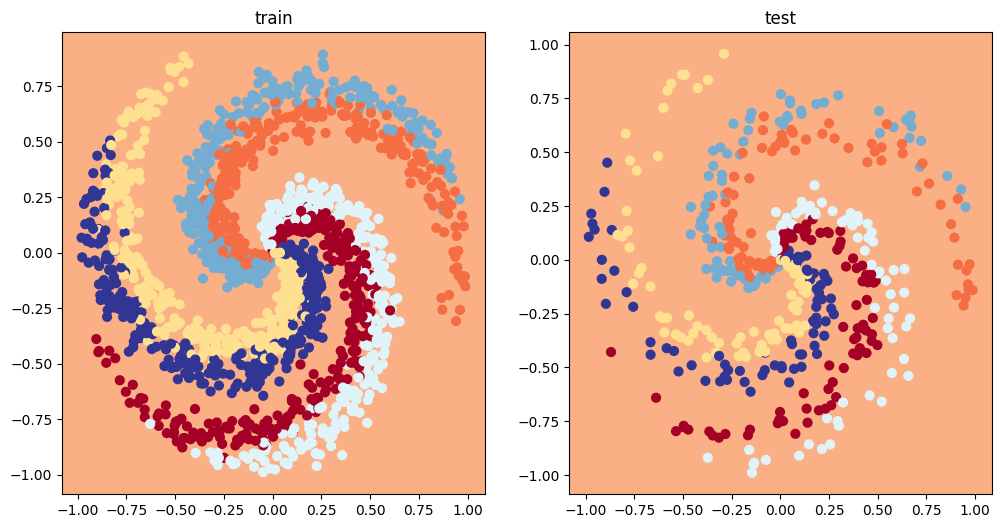

In [43]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_1,x_test,y_test)

In [46]:
# Setup data to be device agnostic
x_train,x_test = x_train.to(device),x_test.to(device)
y_train,y_test = y_train.to(device),y_test.to(device)

model_1.eval()
with torch.inference_mode():
  y_logits = model_1(x_test)
# Print out first 10 untrained model outputs (forward pass)

print("Logits:",y_logits[:5])

y_pred_probs = torch.softmax(y_logits,dim=1)

print("Pred probs:", y_pred_probs[:5])

y_pred = torch.argmax(y_pred_probs,dim=1)
print("Pred labels:", y_pred[:5])
## Your code here ##

Logits: tensor([[ 0.0384,  0.1042,  0.0884,  0.0310, -0.0834, -0.0825],
        [ 0.0363,  0.1048,  0.0915,  0.0307, -0.0838, -0.0808],
        [ 0.0383,  0.1043,  0.0879,  0.0310, -0.0839, -0.0822],
        [ 0.0396,  0.1023,  0.0888,  0.0328, -0.0830, -0.0846],
        [ 0.0386,  0.1040,  0.0885,  0.0310, -0.0832, -0.0829]],
       device='cuda:0')
Pred probs: tensor([[0.1700, 0.1815, 0.1787, 0.1687, 0.1505, 0.1506],
        [0.1695, 0.1816, 0.1792, 0.1686, 0.1503, 0.1508],
        [0.1700, 0.1816, 0.1786, 0.1687, 0.1504, 0.1507],
        [0.1702, 0.1812, 0.1788, 0.1690, 0.1506, 0.1503],
        [0.1700, 0.1815, 0.1787, 0.1687, 0.1505, 0.1506]], device='cuda:0')
Pred labels: tensor([1, 1, 1, 1, 1], device='cuda:0')


In [47]:
# Setup loss function and optimizer
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_1.parameters(),
                            lr=0.1)

In [48]:
# Build a training loop for the model
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
epochs = 3000


# Loop over data
for epoch in range(epochs):

  ## Training
  model_1.train()
  # 1. Forward pass
  logits = model_1(x_train)
  y_pred_probs = torch.softmax(logits,dim=1)
  y_pred = torch.argmax(y_pred_probs, dim=1)
  # 2. Calculate the loss
  loss = loss_fn(logits,y_train)
  acc = acc_fn(y_pred,y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  model_1.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_1(x_test)
    test_pred_prob = torch.softmax(test_logits, dim = 1)
    test_prob = torch.argmax(test_pred_prob,dim=1)
    # 2. Caculate loss and acc
    test_loss = loss_fn(test_logits,y_test)
    test_acc = acc_fn(test_prob,y_test)

  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"epoch: {epoch} | loss :{loss:.2f} | acc:{acc:.2f} | test loss:{test_loss:.2f} | test acc:{test_acc:.2f}")

epoch: 0 | loss :1.79 | acc:0.16 | test loss:1.79 | test acc:0.18
epoch: 100 | loss :1.79 | acc:0.25 | test loss:1.79 | test acc:0.24
epoch: 200 | loss :1.76 | acc:0.21 | test loss:1.76 | test acc:0.20
epoch: 300 | loss :1.57 | acc:0.24 | test loss:1.59 | test acc:0.25
epoch: 400 | loss :1.49 | acc:0.41 | test loss:1.56 | test acc:0.32
epoch: 500 | loss :1.27 | acc:0.39 | test loss:1.37 | test acc:0.37
epoch: 600 | loss :1.04 | acc:0.50 | test loss:1.11 | test acc:0.41
epoch: 700 | loss :1.10 | acc:0.40 | test loss:1.22 | test acc:0.42
epoch: 800 | loss :0.74 | acc:0.64 | test loss:0.77 | test acc:0.58
epoch: 900 | loss :0.65 | acc:0.67 | test loss:0.69 | test acc:0.68
epoch: 1000 | loss :0.66 | acc:0.65 | test loss:0.70 | test acc:0.68
epoch: 1100 | loss :0.56 | acc:0.74 | test loss:0.56 | test acc:0.74
epoch: 1200 | loss :0.88 | acc:0.61 | test loss:0.81 | test acc:0.65
epoch: 1300 | loss :0.48 | acc:0.77 | test loss:0.50 | test acc:0.76
epoch: 1400 | loss :0.58 | acc:0.73 | test los

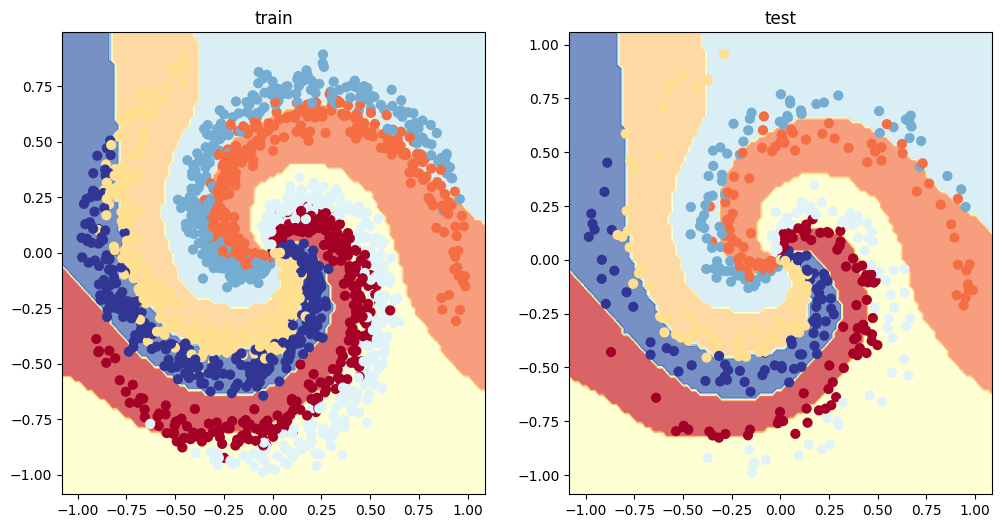

In [49]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_1,x_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_1,x_test,y_test)